In [64]:
# statistical tests and plots to compare the values from 2 different time points
# load the correponding dataset by un-commenting the corresponding line

In [65]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro             # for normality testS
import statsmodels.api as sm                # for linear mixed-effects models (LMM)
import statsmodels.formula.api as smf       # for linear mixed-effects models (LMM)
from statsmodels.formula.api import mixedlm # for LMM
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
# Load shape measures, SELECTED
curRoot = 'C'  # 'C' or 'D'
# NOTE sca7, 3 and 2 relabeled use CS instead of CSSyl, only sca1 use CSSyl as before
curRegion = 'CSSyl'  # CSSyl (SCA1), CS (SCA3,7,2) or CSpreCS 
curSCA = 1      # !!! modify !!!
#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# separating time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# combining time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# combining time1 and time2, after relabelling, for CSpreCS. If CSSyl load RELABEL_REDO instead
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# combining time1 and time2, after relabelling and REDO for sca1
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# combining time1 and time2, after relabelling for sca7, sca3 and sca2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_ori.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_ori.csv'

##########################################################################################################
# different sca
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

combined = pd.read_csv(curPath)
combined.index = combined['subjName']
combined.loc[combined['Time_point'] == 3, 'Time_point'] = 2  ## !!! rename time point 3 to 2, for CERMOI

# for specific analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]
combined_only_ctl = combined[combined['SCA'] == 0]

combined_only_ctl_BIOSCA = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'BIOSCA')]
combined_only_ctl_CERMOI = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'CERMOI')]

combined_CAG = combined.dropna(subset=['CAG', 'Age_onset'])
#combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS', 'Age_onset'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS', 'Age_onset'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]


In [67]:
# For comparison of the same subject across time points, add a column 'ori_subjName' without the time point postfix

# add a column to combined_only_sca 'ori_subjName' without the postfix
# Remove the postfix in the form of '_something'

combined.loc[:,'ori_subjName'] = combined['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_BIOSCA.loc[:, 'ori_subjName'] = combined_only_ctl_BIOSCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_CERMOI.loc[:, 'ori_subjName'] = combined_only_ctl_CERMOI['subjName'].str.replace(r'_.+$', '', regex=True)

combined_CAG_only_SCA.loc[:, 'ori_subjName'] = combined_CAG_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_CCFS_only_SCA.loc[:, 'ori_subjName'] = combined_CCFS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_INAS_only_SCA.loc[:, 'ori_subjName'] = combined_INAS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
#print(combined_only_ctl)

C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\1243336850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\1243336850.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\1243336850.py

In [68]:
# Remove subjects with only one time point

def removeSingleTimePointReIndex(df):
  valid_subjects = df['ori_subjName'].value_counts()   # ensure each subject has two time points
  df = df[df['ori_subjName'].isin(valid_subjects[valid_subjects > 1].index)]
  df = df.sort_values(by=["ori_subjName", "Time_point"]).reset_index(drop=True)    
  return df

combined = removeSingleTimePointReIndex(combined)
combined_only_SCA = removeSingleTimePointReIndex(combined_only_SCA)
combined_CAG_only_SCA = removeSingleTimePointReIndex(combined_CAG_only_SCA)
combined_CCFS_only_SCA = removeSingleTimePointReIndex(combined_CCFS_only_SCA)
combined_INAS_only_SCA = removeSingleTimePointReIndex(combined_INAS_only_SCA)

In [69]:
print(combined_only_SCA['SCA'].tolist())
print(combined_only_ctl['SCA'].tolist())
print()
print(combined['SCA'].tolist())

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


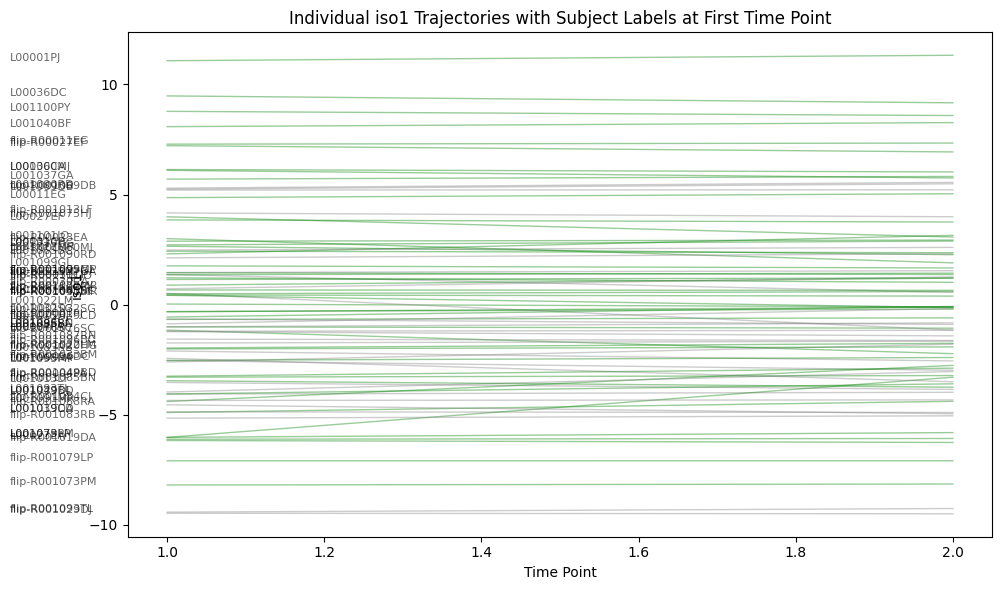

In [70]:
######################   Line plot, quality control   ######################
df = combined
plt.figure(figsize=(10, 6))

#df['SCA'] = df['SCA'].map({0: 'Control', 7: 'SCA7'})  
df['SCA'] = df['SCA'].map({0: 'Control', 3: 'SCA3'})  
#df['SCA'] = df['SCA'].map({0: 'Control', 1: 'SCA1'})  
custom_palette = {'Control': 'green', 'SCA1': 'red'}


# Loop through each subject and plot their line
for subj_id, group_data in df.groupby('ori_subjName'):
    group_color = custom_palette.get(group_data['SCA'].iloc[0], 'gray')

    plt.plot(
        group_data['Time_point'],
        group_data['iso1'],
        alpha=0.4,
        lw=1,
        color=group_color
    )
    
    # Label at first time point
    first_time = group_data['Time_point'].min()
    first_iso = group_data.loc[group_data['Time_point'] == first_time, 'iso1'].values[0]
    plt.text(first_time - 0.2, first_iso, subj_id, fontsize=8, alpha=0.6)

plt.title("Individual iso1 Trajectories with Subject Labels at First Time Point")
plt.xlabel("Time Point")
plt.ylabel("iso1")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_maxIso1_time1_2_QC_sca1_Trajectory.png')

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\2091976850.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


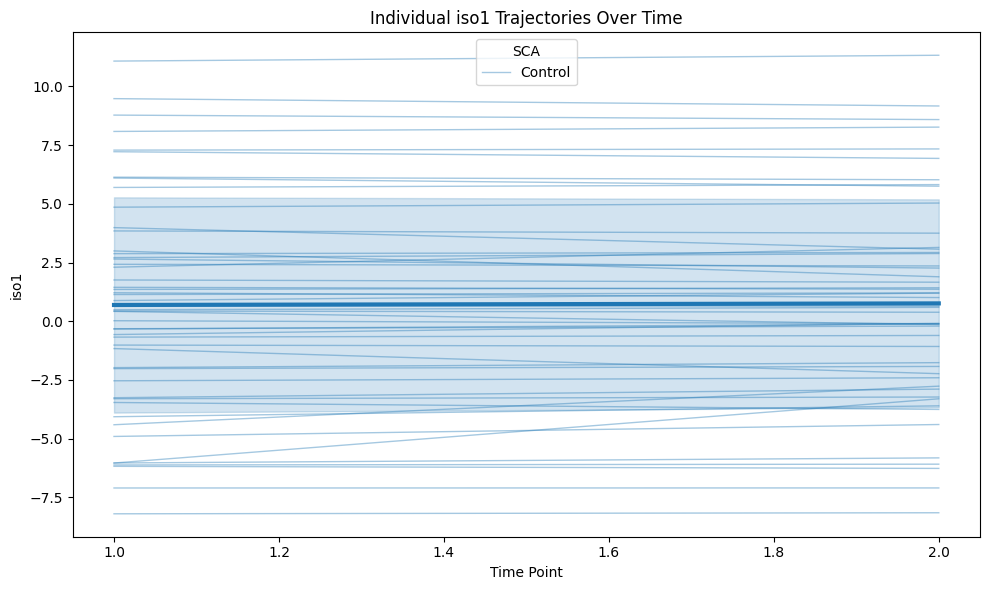

In [71]:
#######################  Visualizing the evolution of values among time_points  #########################

#df = combined_CAG_only_SCA
df = combined

# Example assumes your DataFrame is called df and includes:
# 'iso1' - the outcome variable
# 'Time_point' - time points (e.g., 1, 2, 3)
# 'ori_subjName' - subject ID
# 'SCA' - group (e.g., "SCA1" vs. "control")

plt.figure(figsize=(10, 6))

# Plot individual trajectories
sns.lineplot(
    data=df,
    x="Time_point",
    y="iso1",
    hue="SCA",
    units="ori_subjName",
    estimator=None,
    alpha=0.4,  # semi-transparent lines
    lw=1  # line width
)

# Optional: Add group-level smoothed trend lines
sns.lineplot(
    data=df,
    x="Time_point",
    y="iso1",
    hue="SCA",
    estimator="mean",
    ci="sd",
    lw=3,
    legend=False
)

plt.title("Individual iso1 Trajectories Over Time")
plt.xlabel("Time Point")
plt.ylabel("iso1")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_maxIso1_time1_2_Trajectory.png')

plt.show()


In [72]:
####################################  For SCA7_control only  #####################################

In [73]:
print(combined['ori_subjName'].tolist())
#print(combined['subjName'].tolist())

['L00001PJ', 'L00001PJ', 'L00004PA', 'L00004PA', 'L00011EG', 'L00011EG', 'L00023EA', 'L00023EA', 'L00027EF', 'L00027EF', 'L00030CA', 'L00030CA', 'L00031CP', 'L00031CP', 'L00036DC', 'L00036DC', 'L001013LF', 'L001013LF', 'L001019DA', 'L001019DA', 'L001020HG', 'L001020HG', 'L001022LM', 'L001022LM', 'L001029DJ', 'L001029DJ', 'L001032SG', 'L001032SG', 'L001033BM', 'L001033BM', 'L001037GA', 'L001037GA', 'L001039CD', 'L001039CD', 'L001040BF', 'L001040BF', 'L001049BD', 'L001049BD', 'L001060MJ', 'L001060MJ', 'L001065BC', 'L001065BC', 'L001068RA', 'L001068RA', 'L001069DB', 'L001069DB', 'L001073PM', 'L001073PM', 'L001075HJ', 'L001075HJ', 'L001076SC', 'L001076SC', 'L001077MR', 'L001077MR', 'L001079LP', 'L001079LP', 'L001083RB', 'L001083RB', 'L001084CJ', 'L001084CJ', 'L001085BN', 'L001085BN', 'L001087RN', 'L001087RN', 'L001090RD', 'L001090RD', 'L001091MR', 'L001091MR', 'L001093TL', 'L001093TL', 'L001095MP', 'L001095MP', 'L001096BC', 'L001096BC', 'L001099GL', 'L001099GL', 'L001100PY', 'L001100PY', '

C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\4181460963.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Subject")


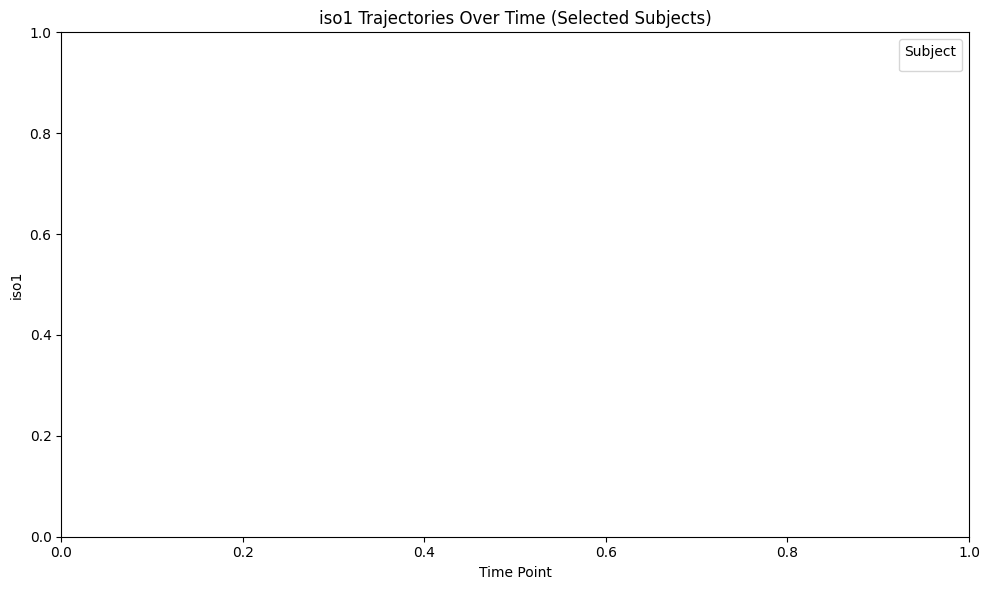

In [74]:
###################  Line plot of the evolution of subjects across time points, NOT across projects  ###################

df = combined
df['ori_subjName'] = df['ori_subjName'].str.strip()

### !!! Modify this list here to add more subjects
# SCA7, known common subjects in BIOSCA (001005DD, 001006DP) and CERMOI (00015DD, 00016DP)
#subject_list = ['L001005DD','flip-R001005DD', 'L001006DP','flip-R001006DP', 'L00015DD','flip-R00015DD','L00016DP','flip-R00016DP','L001010ED','flip-R001010ED','L00018ED','flip-R00018ED']
subject_list = ['L001005DD','flip-R001005DD', 'L001006DP','flip-R001006DP', 'L00015DD','flip-R00015DD','L00016DP','flip-R00016DP',
                'L001010ED','flip-R001010ED','L00018ED','flip-R00018ED',
                'L001009EL','flip-R001009EL', 'L00010DL','flip-R00010DL'
               ]


# Filter the dataframe
df_subset = df[df['ori_subjName'].isin(subject_list)]

plt.figure(figsize=(10, 6))

# Plot individual trajectories
sns.lineplot(
    data=df_subset,
    x="Time_point",
    y="iso1",
    hue="ori_subjName",  # Color lines by subject
    units="ori_subjName",
    estimator=None,
    alpha=0.8,
    lw=2
)

plt.title("iso1 Trajectories Over Time (Selected Subjects)")
plt.xlabel("Time Point")
plt.ylabel("iso1")
plt.tight_layout()
plt.legend(title="Subject")
plt.show()


In [75]:
#print(df_subset)

In [76]:
#######################  create df_new where the mapping from BIOSAC to CERMOI id defined  #######################
### Modify this list here to add more subjects
### !!! Make sure to update the df_subset above FIRST
#name_list_1 = ["L001005DD_E1", "flip_R001005DD_E1","L001006DP_E2","flip_R001006DP_E2"]
#name_list_2 = ["L00015DD_V1", "flip_R00015DD_V1","L00016DP_V3","flip_R00016DP_V3"]
#name_list_1 = ["L001005DD", "flip-R001005DD","L001006DP","flip-R001006DP","L001010ED","flip-R001010ED"]
#name_list_2 = ["L00015DD", "flip-R00015DD","L00016DP","flip-R00016DP","L00018ED","flip-R00018ED"]
name_list_1 = ["L001005DD", "flip-R001005DD","L001006DP","flip-R001006DP","L001010ED","flip-R001010ED","L001009EL","flip-R001009EL"]
name_list_2 = ["L00015DD", "flip-R00015DD","L00016DP","flip-R00016DP","L00018ED","flip-R00018ED","L00010DL","flip-R00010DL"]


# Create a dictionary that maps name_list_2 to name_list_1
name_mapping = dict(zip(name_list_2, name_list_1))

df_new = df_subset.copy()
# Apply the mapping to create a unified_subject column in df_subset
# For subjects not in the mapping, keep their original name
df_new['unified_subject'] = df_new['ori_subjName'].replace(name_mapping)

# Update the subject name and shift time points
for old_name, new_name in name_mapping.items():
    # Locate rows for the "duplicate" subject
    mask = df_new["ori_subjName"] == old_name

    # Rename subject
    df_new.loc[mask, "ori_subjName"] = new_name

    # Shift time points for this subject
    df_new.loc[mask, "Time_point"] += 2


In [77]:
#print(name_mapping)
#print(df_new)
print(set(name_list_2) & set(df_subset['ori_subjName']))

set()


C:\Users\joyca\AppData\Local\Temp\ipykernel_165852\2603892861.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Subject_New")


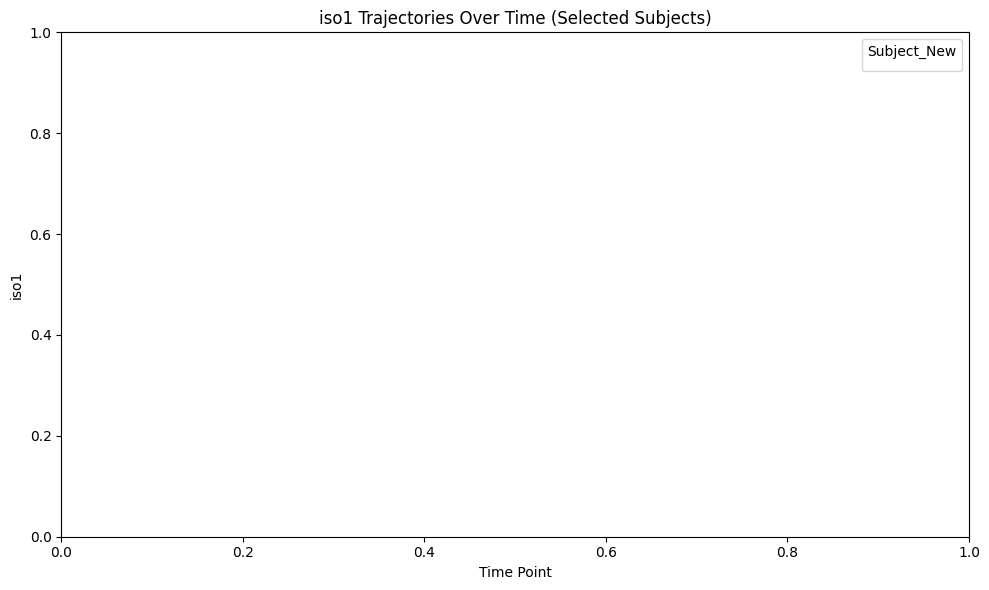

In [78]:
##############################   plotting df_new: the 5 time points together   #############################

plt.figure(figsize=(10, 6))

# Plot individual trajectories
sns.lineplot(
    data=df_new,
    x="Time_point",
    y="iso1",
    #hue="ori_subjName",  # Color lines by subject
    #units="ori_subjName",
    hue="unified_subject",
    units="unified_subject",
    estimator=None,
    alpha=0.8,
    lw=2
)

plt.title("iso1 Trajectories Over Time (Selected Subjects)")
plt.xlabel("Time Point")
plt.ylabel("iso1")
plt.tight_layout()
plt.legend(title="Subject_New")

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7_minIso1_time1_2_overlapSubj_Trajectory.png')

plt.show()
